In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv(r'c:\Users\user\OneDrive\Desktop\Testingspace\.aqi\air_quality_health_dataset.csv')  # or .xlsx, .json, etc.


In [6]:
df.head()

,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
0,Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337
1,Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545
2,London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539
3,Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552
4,Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88489 entries, 0 to 88488
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   city                 88489 non-null  object 
 1   date                 88489 non-null  object 
 2   aqi                  88489 non-null  int64  
 3   pm2_5                88489 non-null  float64
 4   pm10                 88489 non-null  float64
 5   no2                  88489 non-null  float64
 6   o3                   88489 non-null  float64
 7   temperature          88489 non-null  float64
 8   humidity             88489 non-null  int64  
 9   hospital_admissions  88489 non-null  int64  
 10  population_density   88489 non-null  object 
 11  hospital_capacity    88489 non-null  int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 8.1+ MB


In [9]:
df.columns

Index(['city', 'date', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'temperature',
       'humidity', 'hospital_admissions', 'population_density',
       'hospital_capacity'],
      dtype='object')

In [11]:
df.describe()

,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,hospital_capacity
count,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000,88489.000000
mean,249.370182,35.144951,50.118654,30.006211,39.978895,17.522962,56.950966,8.049385,1024.463165
std,144.479132,14.767994,19.796392,9.963139,12.007258,12.961024,21.629675,3.715458,561.978071
min,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,20.000000,0.000000,50.000000
25%,124.000000,24.900000,36.600000,23.300000,31.900000,6.400000,38.000000,6.000000,539.000000
50%,249.000000,35.100000,50.000000,30.000000,40.000000,17.500000,57.000000,8.000000,1026.000000
75%,374.000000,45.200000,63.500000,36.700000,48.100000,28.700000,76.000000,10.000000,1511.000000
max,499.000000,109.900000,143.500000,71.400000,93.500000,40.000000,94.000000,25.000000,1999.000000


In [12]:
df.isnull().sum()

city                   0
date                   0
aqi                    0
pm2_5                  0
pm10                   0
no2                    0
o3                     0
temperature            0
humidity               0
hospital_admissions    0
population_density     0
hospital_capacity      0
dtype: int64

In [15]:
df.dropna(inplace=True)             # remove rows with missing data
df.drop(columns=['city', 'date', 'aqi', 'pm2_5', 'pm10', 'no2', 'o3', 'temperature',
       'humidity', 'hospital_admissions', 'population_density',
       'hospital_capacity'], inplace=True)  # drop a specific column


In [18]:
print(df.head())
print(df.shape)


Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]
(88489, 0)


In [19]:
df = pd.read_csv(r'C:\Users\user\OneDrive\Desktop\Testingspace\.aqi\air_quality_health_dataset.csv')


In [20]:
with open(r'C:\Users\user\OneDrive\Desktop\Testingspace\.aqi\air_quality_health_dataset.csv', 'r') as f:
    for i in range(10):
        print(f.readline())

city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity

Los Angeles,2020-01-01,65,34.0,52.7,2.2,38.5,33.5,33,5,Rural,1337

Beijing,2020-01-02,137,33.7,31.5,36.7,27.5,-1.6,32,4,Urban,1545

London,2020-01-03,266,43.0,59.6,30.4,57.3,36.4,25,10,Suburban,1539

Mexico City,2020-01-04,293,33.7,37.9,12.3,42.7,-1.0,67,10,Urban,552

Delhi,2020-01-05,493,50.3,34.8,31.2,35.6,33.5,72,9,Suburban,1631

Cairo,2020-01-06,28,67.2,44.9,41.9,47.8,7.9,89,11,Urban,1291

Los Angeles,2020-01-07,217,29.0,63.7,22.3,56.0,27.7,22,8,Urban,1852

Los Angeles,2020-01-08,449,60.8,56.2,40.0,18.1,26.3,46,14,Urban,350

Delhi,2020-01-09,342,44.9,63.4,31.0,34.9,28.0,34,7,Urban,878



In [22]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Keep only rows within the IQR bounds for all numeric columns
df_cleaned = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]


In [23]:
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")


Original shape: (88489, 12)
Cleaned shape: (85359, 12)


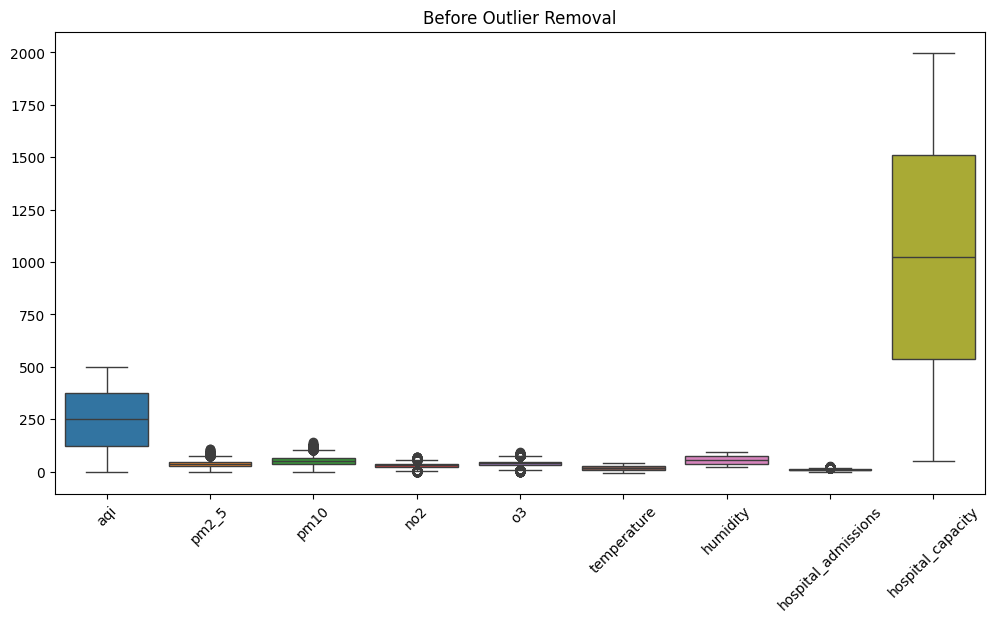

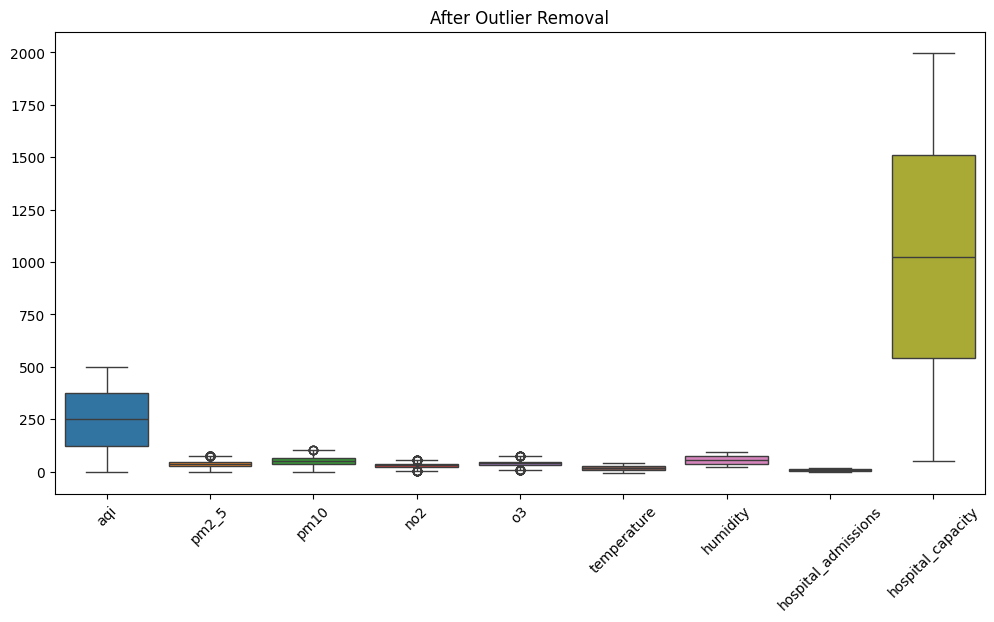

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols])
plt.title("Before Outlier Removal")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[numeric_cols])
plt.title("After Outlier Removal")
plt.xticks(rotation=45)
plt.show()


In [26]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [27]:
df = df.dropna(subset=['date'])


In [28]:
print(df['date'].isnull().sum())  # Should be 0
print(df['date'].min(), df['date'].max())  # Check date range


0
2020-01-01 00:00:00 2262-04-10 00:00:00


In [29]:
df = df[(df['date'] >= '2010-01-01') & (df['date'] <= '2025-12-31')]


In [30]:
print(df['date'].isnull().sum())  # Should be 0
print(df['date'].min(), df['date'].max())  # Check date range


0
2020-01-01 00:00:00 2025-12-31 00:00:00


In [31]:
df.tail()

,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
2187,Mexico City,2025-12-27,223,38.4,43.3,36.1,46.2,9.2,93,9,Urban,1959
2188,Delhi,2025-12-28,40,51.3,34.5,35.9,26.4,30.1,79,8,Urban,1814
2189,Tokyo,2025-12-29,55,43.2,79.4,34.2,58.8,9.1,73,12,Suburban,778
2190,Delhi,2025-12-30,420,54.5,33.6,45.0,21.2,30.2,92,12,Suburban,605
2191,Mexico City,2025-12-31,454,54.3,23.9,40.4,54.4,18.7,67,9,Urban,1930


In [33]:
df_cleaned.to_csv("cleaned1_air_quality_data.csv", index=False)


In [34]:
df.tail()

,city,date,aqi,pm2_5,pm10,no2,o3,temperature,humidity,hospital_admissions,population_density,hospital_capacity
2187,Mexico City,2025-12-27,223,38.4,43.3,36.1,46.2,9.2,93,9,Urban,1959
2188,Delhi,2025-12-28,40,51.3,34.5,35.9,26.4,30.1,79,8,Urban,1814
2189,Tokyo,2025-12-29,55,43.2,79.4,34.2,58.8,9.1,73,12,Suburban,778
2190,Delhi,2025-12-30,420,54.5,33.6,45.0,21.2,30.2,92,12,Suburban,605
2191,Mexico City,2025-12-31,454,54.3,23.9,40.4,54.4,18.7,67,9,Urban,1930


In [36]:
import pandas as pd
from scipy import stats
import numpy as np

# Step 1: Load the dataset
df = pd.read_csv('cleaned1_air_quality_data.csv')

# Step 2: Parse date column properly
df['date'] = pd.to_datetime(df['date'], errors='coerce')  # invalid dates become NaT

# Step 3: Filter out rows with invalid or future dates
df = df[df['date'].notna()]  # remove NaT
df = df[df['date'].dt.year <= 2025]

# Step 4: Drop duplicates and missing values
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Step 5: Remove outliers using Z-score (for numeric columns only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
z_scores = np.abs(stats.zscore(df[numeric_cols]))
df = df[(z_scores < 3).all(axis=1)]  # keeps rows where all z-scores < 3

# Step 6: Save the cleaned dataset
df.to_csv('cleaned_air_quality_data_final.csv', index=False)

print("Cleaned data saved as 'cleaned_air_quality_data_final.csv'.")


Cleaned data saved as 'cleaned_air_quality_data_final.csv'.


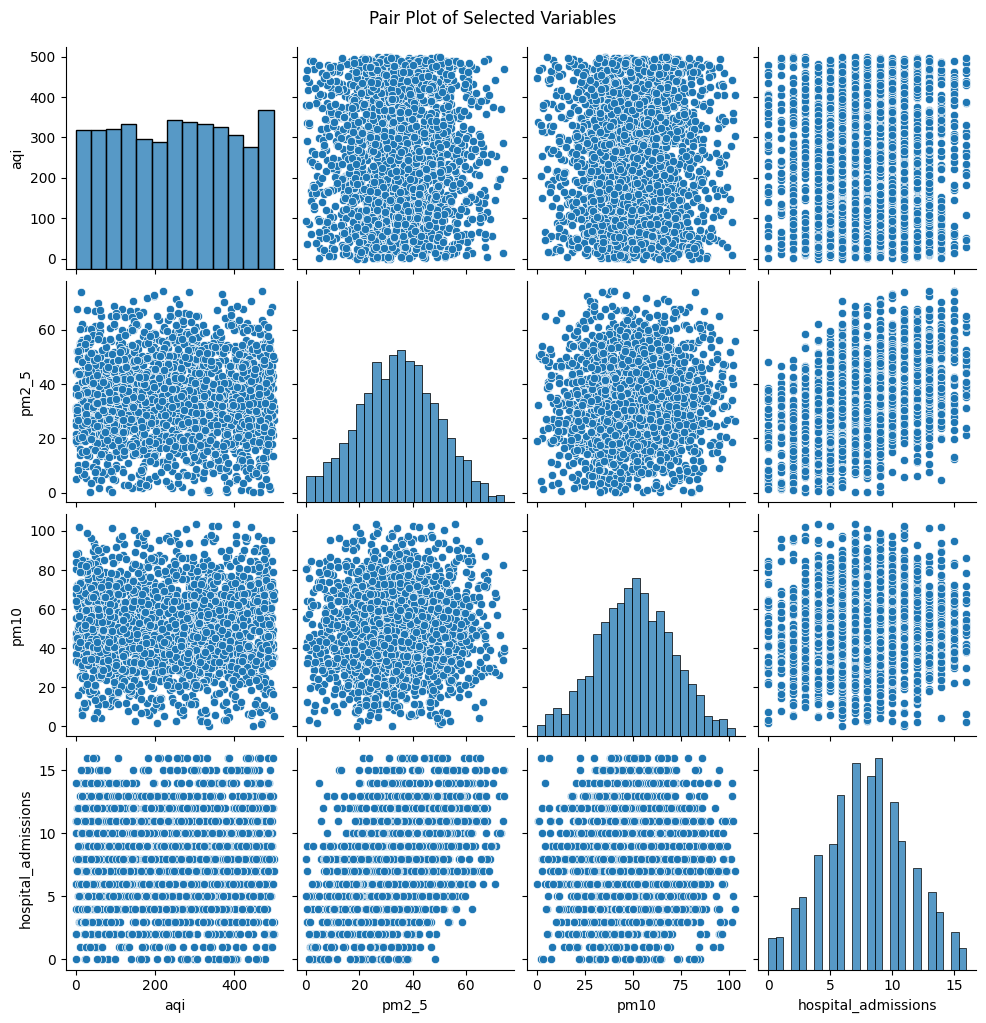

In [37]:
sns.pairplot(df[['aqi', 'pm2_5', 'pm10', 'hospital_admissions']])
plt.suptitle('Pair Plot of Selected Variables', y=1.02)
plt.savefig('pairplot.png')
plt.show()